In [4]:
pip install pybullet matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 MB 10.3 MB/s eta 0:00:00


In [5]:
import pybullet as pb
import pybullet_data as pd
import numpy as np
import matplotlib.pyplot as mp
import os
import tempfile as tf


In [7]:
def tb():
    return '''<?xml version="1.0"?>
<robot name="tb">
  <link name="t">
    <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><box size="1.0 0.7 0.05"/></geometry>
      <material name="w"><color rgba="0.6 0.4 0.2 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><box size="1.0 0.7 0.05"/></geometry>
    </collision>
    <inertial>
      <mass value="5.0"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.1"/>
    </inertial>
  </link>
</robot>'''

def pl():
    return '''<?xml version="1.0"?>
<robot name="pl">
  <link name="b">
    <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><cylinder radius="0.2" length="0.1"/></geometry>
      <material name="c"><color rgba="0.7 0.7 0.7 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><cylinder radius="0.2" length="0.1"/></geometry>
    </collision>
    <inertial>
      <mass value="8.0"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.1"/>
    </inertial>
  </link>
  <link name="c">
    <visual>
      <origin xyz="0 0 0.7" rpy="0 0 0"/>
      <geometry><cylinder radius="0.12" length="1.4"/></geometry>
      <material name="c"><color rgba="0.7 0.7 0.7 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0.7" rpy="0 0 0"/>
      <geometry><cylinder radius="0.12" length="1.4"/></geometry>
    </collision>
    <inertial>
      <mass value="10.0"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.1"/>
    </inertial>
  </link>
  <joint name="j" type="fixed">
    <parent link="b"/>
    <child link="c"/>
    <origin xyz="0 0 0.05" rpy="0 0 0"/>
  </joint>
</robot>'''

def wl():
    return '''<?xml version="1.0"?>
<robot name="wl">
  <link name="w">
    <visual>
      <origin xyz="0 0 1.0" rpy="0 0 0"/>
      <geometry><box size="2.5 0.15 2.0"/></geometry>
      <material name="b"><color rgba="0.8 0.6 0.4 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 1.0" rpy="0 0 0"/>
      <geometry><box size="2.5 0.15 2.0"/></geometry>
    </collision>
    <inertial>
      <mass value="30.0"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.1"/>
    </inertial>
  </link>
</robot>'''

def pf():
    return '''<?xml version="1.0"?>
<robot name="pf">
  <link name="s">
    <visual>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><box size="1.4 1.4 0.08"/></geometry>
      <material name="m"><color rgba="0.5 0.5 0.6 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0" rpy="0 0 0"/>
      <geometry><box size="1.4 1.4 0.08"/></geometry>
    </collision>
    <inertial>
      <mass value="12.0"/>
      <inertia ixx="0.1" ixy="0" ixz="0" iyy="0.1" iyz="0" izz="0.1"/>
    </inertial>
  </link>
</robot>'''

def dt():
    return '''<?xml version="1.0"?>
<robot name="dt">
  <link name="d">
    <visual>
      <origin xyz="0 0 0.35" rpy="0 0 0"/>
      <geometry><box size="1.5 1.5 0.07"/></geometry>
      <material name="w"><color rgba="0.7 0.5 0.3 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0.35" rpy="0 0 0"/>
      <geometry><box size="1.5 1.5 0.07"/></geometry>
    </collision>
    <inertial>
      <mass value="9.0"/>
      <inertia ixx="0.2" ixy="0" ixz="0" iyy="0.2" iyz="0" izz="0.2"/>
    </inertial>
  </link>
</robot>'''

def ch():
    return '''<?xml version="1.0"?>
<robot name="ch">
  <link name="c">
    <visual>
      <origin xyz="0 0 0.25" rpy="0 0 0"/>
      <geometry><box size="0.4 0.4 0.5"/></geometry>
      <material name="b"><color rgba="0.3 0.3 0.3 1"/></material>
    </visual>
    <collision>
      <origin xyz="0 0 0.25" rpy="0 0 0"/>
      <geometry><box size="0.4 0.4 0.5"/></geometry>
    </collision>
    <inertial>
      <mass value="2.0"/>
      <inertia ixx="0.05" ixy="0" ixz="0" iyy="0.05" iyz="0" izz="0.05"/>
    </inertial>
  </link>
</robot>'''


In [8]:
dir = tf.mkdtemp()
with open(os.path.join(dir, 'tb.urdf'), 'w') as f: f.write(tb())
with open(os.path.join(dir, 'pl.urdf'), 'w') as f: f.write(pl())
with open(os.path.join(dir, 'wl.urdf'), 'w') as f: f.write(wl())
with open(os.path.join(dir, 'pf.urdf'), 'w') as f: f.write(pf())
with open(os.path.join(dir, 'dt.urdf'), 'w') as f: f.write(dt())
with open(os.path.join(dir, 'ch.urdf'), 'w') as f: f.write(ch())


In [9]:
pb.connect(pb.DIRECT)
pb.setAdditionalSearchPath(pd.getDataPath())
pb.setGravity(0, 0, -9.81)
pb.loadURDF('plane.urdf')


0

In [10]:
print("URDF directory:", dir)
print("Files in directory:", os.listdir(dir))
print("tb.urdf exists:", os.path.exists(os.path.join(dir, 'tb.urdf')))
print("pl.urdf exists:", os.path.exists(os.path.join(dir, 'pl.urdf')))
print("wl.urdf exists:", os.path.exists(os.path.join(dir, 'wl.urdf')))
print("pf.urdf exists:", os.path.exists(os.path.join(dir, 'pf.urdf')))
id = {}
id['t1'] = pb.loadURDF(os.path.join(dir, 'tb.urdf'), [2, 1, 0.75], [0, 0, 0.707, 0.707])
id['t2'] = pb.loadURDF(os.path.join(dir, 'tb.urdf'), [-1, -2, 0.75], [0, 0, 0, 1])
id['p1'] = pb.loadURDF(os.path.join(dir, 'pl.urdf'), [0, 2, 0], [0, 0, 0, 1])
id['p2'] = pb.loadURDF(os.path.join(dir, 'pl.urdf'), [3, -2, 0], [0, 0, 0, 1])
id['w1'] = pb.loadURDF(os.path.join(dir, 'wl.urdf'), [0, 3, 0], [0, 0, 0, 1])
id['w2'] = pb.loadURDF(os.path.join(dir, 'wl.urdf'), [-3, 0, 0], [0, 0, 0.707, 0.707])
id['pf1'] = pb.loadURDF(os.path.join(dir, 'pf.urdf'), [2, -2, 0.4], [0, 0, 0, 1])
id['dt1'] = pb.loadURDF(os.path.join(dir, 'dt.urdf'), [1.5, 3, 0.35], [0, 0, 0, 1])
id['ch1'] = pb.loadURDF(os.path.join(dir, 'ch.urdf'), [1.8, 3.8, 0.25], [0, 0, 0, 1])
id['ch2'] = pb.loadURDF(os.path.join(dir, 'ch.urdf'), [1.2, 2.2, 0.25], [0, 0, 0, 1])


URDF directory: /tmp/tmp9vpn2b5f
Files in directory: ['wl.urdf', 'ch.urdf', 'tb.urdf', 'pl.urdf', 'pf.urdf', 'dt.urdf']
tb.urdf exists: True
pl.urdf exists: True
wl.urdf exists: True
pf.urdf exists: True


In [11]:
def cv(cp, tp, up, nm, w=400, h=300):
    vm = pb.computeViewMatrix(cp, tp, up)
    pm = pb.computeProjectionMatrixFOV(fov=60, aspect=w/h, nearVal=0.1, farVal=100)
    _, _, im, _, _ = pb.getCameraImage(width=w, height=h, viewMatrix=vm, projectionMatrix=pm, renderer=pb.ER_BULLET_HARDWARE_OPENGL)
    return np.array(im).reshape(h, w, 4)[:, :, :3]

im1 = cv([0, 4, 7], [0, 0, 0], [0, 1, 0], 'Top')
im2 = cv([-5, -2, 1.3], [1, 1, 0.7], [0, 0, 1], 'Low')
im3 = cv([4, -3, 2], [0, 1, 1], [0, 0, 1], 'Angled')


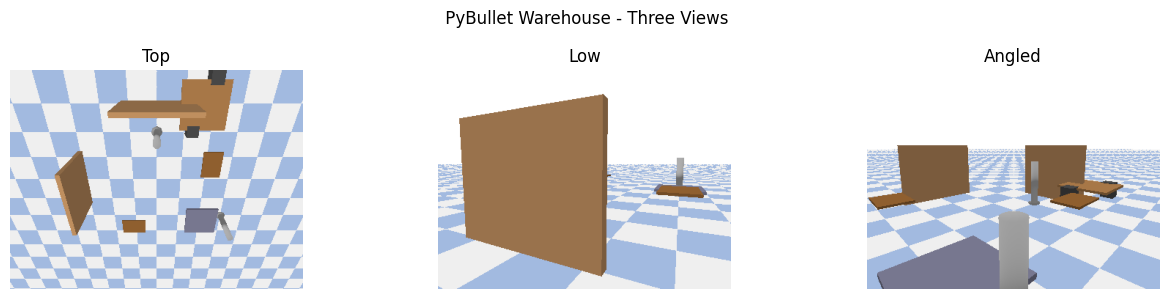

In [12]:
fg, ax = mp.subplots(1, 3, figsize=(13, 3))
ax[0].imshow(im1); ax[0].set_title('Top')
ax[1].imshow(im2); ax[1].set_title('Low')
ax[2].imshow(im3); ax[2].set_title('Angled')
for a in ax: a.axis('off')
mp.suptitle(' PyBullet Warehouse - Three Views')
mp.tight_layout()
mp.show()

In [13]:
pb.disconnect()
